# 📈 FinSentiment Stock Predictor — Model Training

This notebook builds the full pipeline:
1. Fetch 2 years of price data for AAPL, TSLA, MSFT, GOOGL using yfinance
2. Fetch historical news headlines using NewsAPI
3. Run FinBERT sentiment analysis on each headline
4. Engineer technical features from price data
5. Combine sentiment + technical features
6. Train XGBoost to predict next-day price movement
7. Evaluate and save model

---
## 1. Install & Import

In [87]:
!pip install yfinance transformers torch newsapi-python --quiet

In [88]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
import joblib
import warnings
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
print('All libraries loaded.')

All libraries loaded.


---
## 2. Configuration

In [89]:
# ── CONFIG ──────────────────────────────────────────
NEWS_API_KEY = "dd968efcdcf94bdb93bd588618434e3e"   # ← paste your regenerated key

TICKERS = {
    "AAPL": "Apple",
    "TSLA": "Tesla",
    "MSFT": "Microsoft",
    "GOOGL": "Google"
}

# Date range — 1 year of data
END_DATE   = datetime.now()
START_DATE = END_DATE - timedelta(days=365)

print(f'Date range: {START_DATE.date()} → {END_DATE.date()}')
print(f'Tickers: {list(TICKERS.keys())}')

Date range: 2025-03-19 → 2026-03-19
Tickers: ['AAPL', 'TSLA', 'MSFT', 'GOOGL']


---
## 3. Fetch Price Data with yfinance

In [90]:
def fetch_price_data(ticker, start, end):
    stock = yf.Ticker(ticker)
    df = stock.history(start=start, end=end)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.index = df.index.normalize()
    return df

price_data = {}
for ticker in TICKERS:
    price_data[ticker] = fetch_price_data(ticker, START_DATE, END_DATE)
    print(f'{ticker}: {len(price_data[ticker])} trading days')

AAPL: 251 trading days
TSLA: 251 trading days
MSFT: 251 trading days
GOOGL: 251 trading days


---
## 4. Technical Feature Engineering

Standard quant features: moving averages, RSI, momentum, volatility.

In [91]:
def add_technical_features(df):
    df = df.copy()

    # Returns
    df['daily_return']  = df['Close'].pct_change()
    df['return_2d']     = df['Close'].pct_change(2)
    df['return_5d']     = df['Close'].pct_change(5)

    # Moving averages
    df['ma5']  = df['Close'].rolling(5).mean()
    df['ma10'] = df['Close'].rolling(10).mean()
    df['ma20'] = df['Close'].rolling(20).mean()

    # Price vs moving averages
    df['price_vs_ma5']  = df['Close'] / df['ma5']  - 1
    df['price_vs_ma10'] = df['Close'] / df['ma10'] - 1
    df['price_vs_ma20'] = df['Close'] / df['ma20'] - 1

    # Volatility
    df['volatility_5d']  = df['daily_return'].rolling(5).std()
    df['volatility_10d'] = df['daily_return'].rolling(10).std()

    # Volume
    df['volume_change']  = df['Volume'].pct_change()
    df['volume_ma5']     = df['Volume'].rolling(5).mean()
    df['volume_vs_ma5']  = df['Volume'] / df['volume_ma5'] - 1

    # High-low range
    df['high_low_range'] = (df['High'] - df['Low']) / df['Close']

    # RSI (14)
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df['rsi'] = 100 - (100 / (1 + rs))

    # Target: did price go UP next day?
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    return df

# Apply to all tickers
for ticker in TICKERS:
    price_data[ticker] = add_technical_features(price_data[ticker])
    print(f'{ticker}: {price_data[ticker].shape}')

AAPL: (251, 22)
TSLA: (251, 22)
MSFT: (251, 22)
GOOGL: (251, 22)


---
## 5. Fetch News Headlines

NewsAPI free tier allows 100 requests/day. We fetch per ticker per month to stay within limits.

In [92]:
# ── CELL 5 — Fetch News Headlines (free tier compatible) ─────────────

def fetch_news_for_ticker(ticker, api_key, page_size=100):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": f"{ticker} stock",
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size,
        "apiKey": api_key
    }
    try:
        resp = requests.get(url, params=params, timeout=15)
        data = resp.json()
        articles = data.get("articles", [])
        results = []
        for a in articles:
            if a.get("title") and "[Removed]" not in a["title"]:
                results.append({
                    "ticker": ticker,
                    "title": a["title"],
                    "date": a["publishedAt"][:10]
                })
        return results
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return []

# Fetch for all tickers
all_news = []
for ticker in TICKERS:
    print(f"Fetching news for {ticker}...")
    articles = fetch_news_for_ticker(ticker, NEWS_API_KEY)
    all_news.extend(articles)
    print(f"  Got {len(articles)} articles")
    time.sleep(1)  # avoid rate limiting

# Guard against empty results
if not all_news:
    raise ValueError("No articles fetched. Check your API key.")

news_df = pd.DataFrame(all_news)
news_df['date'] = pd.to_datetime(news_df['date'])

print(f"\nTotal articles: {len(news_df)}")
print(news_df['ticker'].value_counts())
news_df.head()

Fetching news for AAPL...
  Got 60 articles
Fetching news for TSLA...
  Got 57 articles
Fetching news for MSFT...
  Got 67 articles
Fetching news for GOOGL...
  Got 55 articles

Total articles: 239
ticker
MSFT     67
AAPL     60
TSLA     57
GOOGL    55
Name: count, dtype: int64


,ticker,title,date
0,AAPL,Launch an autonomous AI agent with sandboxed e...,2026-03-18
1,AAPL,Apple Just Announced the AirPods Max 2. Can Th...,2026-03-17
2,AAPL,Is Apple Inc. (AAPL) A Good Stock To Buy Now?,2026-03-16
3,AAPL,adanos-cli 1.20.2,2026-03-15
4,AAPL,"Rosenblatt Lifts Price Target on Apple by $1, ...",2026-03-13


---
## 6. FinBERT Sentiment Analysis

ProsusAI/finbert is a BERT model fine-tuned specifically on financial text — it outperforms generic sentiment models on financial news.

In [93]:
print('Loading FinBERT...')
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    return_all_scores=True
)
print('FinBERT loaded.')

Loading FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded.


In [94]:
def score_sentiment(title):
    try:
        scores = finbert(title[:512])[0]
        score_dict = {s['label']: s['score'] for s in scores}
        label = max(score_dict, key=score_dict.get)
        return pd.Series({
            'sentiment': label,
            'positive':  score_dict.get('positive', 0),
            'negative':  score_dict.get('negative', 0),
            'neutral':   score_dict.get('neutral', 0),
            'confidence': score_dict.get(label, 0)
        })
    except:
        return pd.Series({
            'sentiment': 'neutral',
            'positive': 0, 'negative': 0,
            'neutral': 1, 'confidence': 1
        })

print(f'Scoring sentiment for {len(news_df)} headlines...')
sentiment_scores = news_df['title'].apply(score_sentiment)
news_df = pd.concat([news_df, sentiment_scores], axis=1)

print('Done.')
print(news_df['sentiment'].value_counts())
news_df.head()

Scoring sentiment for 239 headlines...
Done.
sentiment
neutral    239
Name: count, dtype: int64


,ticker,title,date,sentiment,positive,negative,neutral,confidence
0,AAPL,Launch an autonomous AI agent with sandboxed e...,2026-03-18,neutral,0,0,1,1
1,AAPL,Apple Just Announced the AirPods Max 2. Can Th...,2026-03-17,neutral,0,0,1,1
2,AAPL,Is Apple Inc. (AAPL) A Good Stock To Buy Now?,2026-03-16,neutral,0,0,1,1
3,AAPL,adanos-cli 1.20.2,2026-03-15,neutral,0,0,1,1
4,AAPL,"Rosenblatt Lifts Price Target on Apple by $1, ...",2026-03-13,neutral,0,0,1,1


---
## 7. EDA — Sentiment Analysis

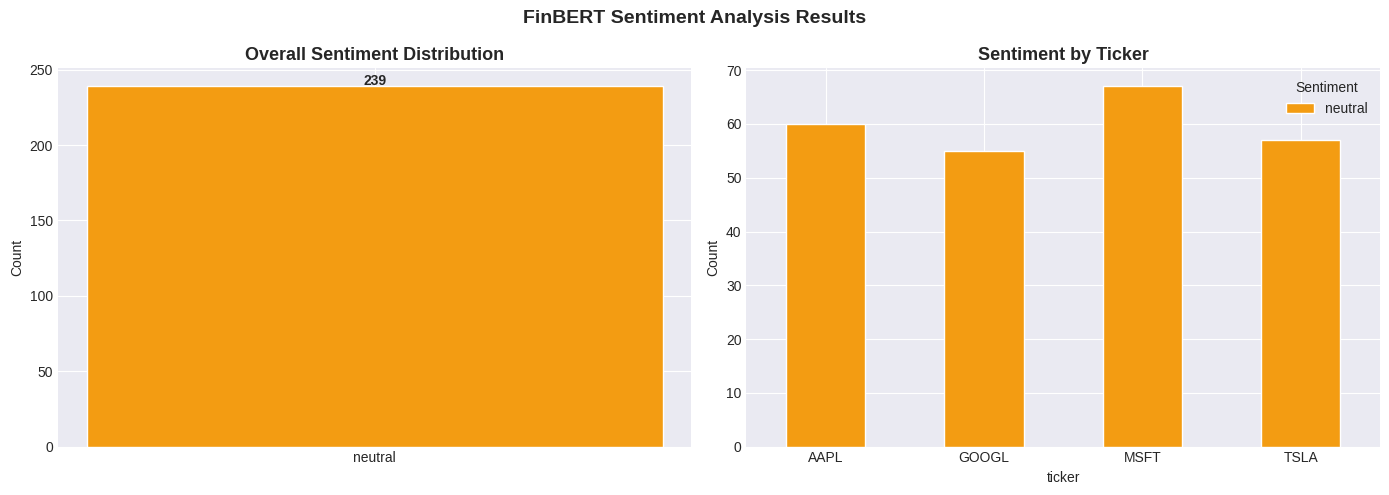

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall sentiment distribution
sent_counts = news_df['sentiment'].value_counts()
colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#f39c12'}
axes[0].bar(sent_counts.index,
            sent_counts.values,
            color=[colors.get(s, '#3498db') for s in sent_counts.index],
            edgecolor='white')
axes[0].set_title('Overall Sentiment Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Sentiment by ticker
ticker_sent = news_df.groupby(['ticker', 'sentiment']).size().unstack(fill_value=0)
ticker_sent.plot(kind='bar', ax=axes[1],
                 color=[colors.get(c, '#3498db') for c in ticker_sent.columns],
                 edgecolor='white')
axes[1].set_title('Sentiment by Ticker', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.suptitle('FinBERT Sentiment Analysis Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

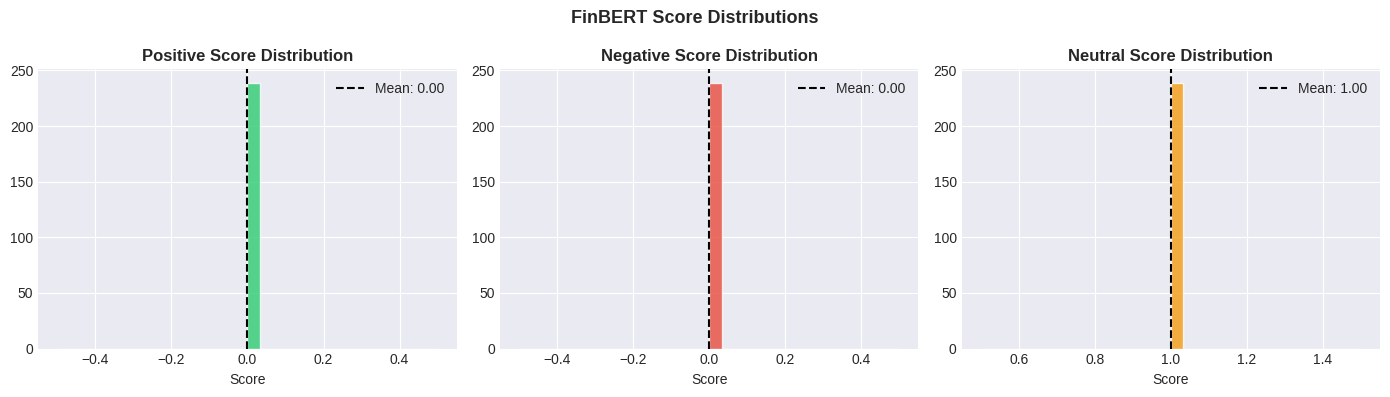

In [96]:
# Sentiment score distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(['positive', 'negative', 'neutral']):
    axes[i].hist(news_df[col], bins=30,
                 color=list(colors.values())[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{col.title()} Score Distribution', fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].axvline(news_df[col].mean(), color='black',
                    linestyle='--', label=f'Mean: {news_df[col].mean():.2f}')
    axes[i].legend()

plt.suptitle('FinBERT Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Aggregate Daily Sentiment

Combine all headlines per ticker per day into a single daily sentiment signal.

In [97]:
daily_sentiment = news_df.groupby(['ticker', 'date']).agg(
    avg_positive  = ('positive',  'mean'),
    avg_negative  = ('negative',  'mean'),
    avg_neutral   = ('neutral',   'mean'),
    avg_confidence= ('confidence','mean'),
    n_articles    = ('title',     'count'),
    positive_ratio= ('sentiment', lambda x: (x == 'positive').mean()),
    negative_ratio= ('sentiment', lambda x: (x == 'negative').mean()),
).reset_index()

daily_sentiment['sentiment_score'] = (
    daily_sentiment['avg_positive'] - daily_sentiment['avg_negative']
)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

print(f'Daily sentiment records: {len(daily_sentiment)}')
daily_sentiment.head()

Daily sentiment records: 97


,ticker,date,avg_positive,avg_negative,avg_neutral,avg_confidence,n_articles,positive_ratio,negative_ratio,sentiment_score
0,AAPL,2026-02-18,0.0000,0.0000,1.0000,1.0000,4,0.0000,0.0000,0.0000
1,AAPL,2026-02-19,0.0000,0.0000,1.0000,1.0000,4,0.0000,0.0000,0.0000
2,AAPL,2026-02-20,0.0000,0.0000,1.0000,1.0000,2,0.0000,0.0000,0.0000
3,AAPL,2026-02-21,0.0000,0.0000,1.0000,1.0000,1,0.0000,0.0000,0.0000
4,AAPL,2026-02-23,0.0000,0.0000,1.0000,1.0000,4,0.0000,0.0000,0.0000


---
## 9. Merge Sentiment + Price Features

In [98]:
all_data = []

for ticker in TICKERS:
    price_df = price_data[ticker].copy().reset_index()
    price_df.columns = [c.lower() for c in price_df.columns]
    price_df = price_df.rename(columns={'date': 'date'})
    price_df['date'] = pd.to_datetime(price_df['date'])
    price_df['ticker'] = ticker

    # Get sentiment for this ticker
    sent_df = daily_sentiment[daily_sentiment['ticker'] == ticker].copy()

    # Merge on date
    merged = pd.merge(price_df, sent_df.drop('ticker', axis=1),
                      on='date', how='left')

    # Fill missing sentiment with neutral defaults
    sent_cols = ['avg_positive', 'avg_negative', 'avg_neutral',
                 'avg_confidence', 'n_articles', 'positive_ratio',
                 'negative_ratio', 'sentiment_score']
    for col in sent_cols:
        if col == 'avg_neutral' or col == 'avg_confidence':
            merged[col] = merged[col].fillna(1.0)
        elif col == 'sentiment_score':
            merged[col] = merged[col].fillna(0.0)
        else:
            merged[col] = merged[col].fillna(0.0)

    all_data.append(merged)

df = pd.concat(all_data, ignore_index=True)
print(f'Combined dataset shape: {df.shape}')
df.head()

Combined dataset shape: (1004, 32)


,date,open,high,low,close,volume,daily_return,return_2d,return_5d,ma5,...,target,ticker,avg_positive,avg_negative,avg_neutral,avg_confidence,n_articles,positive_ratio,negative_ratio,sentiment_score
0,2025-03-19,213.2904,217.8107,212.8224,214.3060,54385400,NaN,NaN,NaN,NaN,...,0,AAPL,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
1,2025-03-20,213.0614,216.5462,211.2991,213.1709,48862900,-0.0053,NaN,NaN,NaN,...,1,AAPL,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
2,2025-03-21,210.6419,217.8903,210.3631,217.3228,94127800,0.0195,0.0141,NaN,NaN,...,1,AAPL,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
3,2025-03-24,220.0410,220.5189,217.6315,219.7721,44299500,0.0113,0.0310,NaN,NaN,...,1,AAPL,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000
4,2025-03-25,219.8120,223.1275,219.1250,222.7791,34493600,0.0137,0.0251,NaN,217.4702,...,0,AAPL,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000


---
## 10. Prepare for Modeling

In [99]:
feature_cols = [
    # Technical
    'daily_return', 'return_2d', 'return_5d',
    'price_vs_ma5', 'price_vs_ma10', 'price_vs_ma20',
    'volatility_5d', 'volatility_10d',
    'volume_change', 'volume_vs_ma5',
    'high_low_range', 'rsi',
    # Sentiment
    'avg_positive', 'avg_negative', 'avg_neutral',
    'avg_confidence', 'n_articles',
    'positive_ratio', 'negative_ratio', 'sentiment_score'
]

# Keep only feature cols + target, drop NaN rows
model_df = df[feature_cols + ['target', 'ticker', 'date']].dropna()

print(f'Modeling dataset shape: {model_df.shape}')
print(f'Target distribution:')
print(model_df['target'].value_counts())
print(f'UP: {model_df["target"].mean():.1%}')

Modeling dataset shape: (928, 23)
Target distribution:
target
1    495
0    433
Name: count, dtype: int64
UP: 53.3%


In [100]:
# Time-based split — use last 20% of dates as test (no data leakage)
model_df = model_df.sort_values('date')
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df['target']
X_test  = test_df[feature_cols]
y_test  = test_df['target']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train period: {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test period:  {test_df["date"].min().date()} → {test_df["date"].max().date()}')

Train: (742, 20) | Test: (186, 20)
Train period: 2025-04-15 → 2026-01-09
Test period:  2026-01-09 → 2026-03-18


---
## 11. Model Training

In [101]:
# Logistic Regression baseline
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1])
print(f'Logistic Regression ROC-AUC: {auc_lr:.4f}')

Training Logistic Regression...
Logistic Regression ROC-AUC: 0.5118


In [102]:
# XGBoost
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f'XGBoost ROC-AUC: {auc_xgb:.4f}')

Training XGBoost...
XGBoost ROC-AUC: 0.5290


In [103]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [auc_lr, auc_xgb]
}).sort_values('ROC-AUC', ascending=False)

print('=== Model Comparison ===')
print(results.to_string(index=False))

=== Model Comparison ===
              Model  ROC-AUC
            XGBoost   0.5290
Logistic Regression   0.5118


---
## 12. Evaluation

In [104]:
y_pred_xgb = xgb_model.predict(X_test)
print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['DOWN', 'UP']))

XGBoost Classification Report:
              precision    recall  f1-score   support

        DOWN       0.60      0.24      0.34       103
          UP       0.46      0.80      0.58        83

    accuracy                           0.49       186
   macro avg       0.53      0.52      0.46       186
weighted avg       0.53      0.49      0.45       186



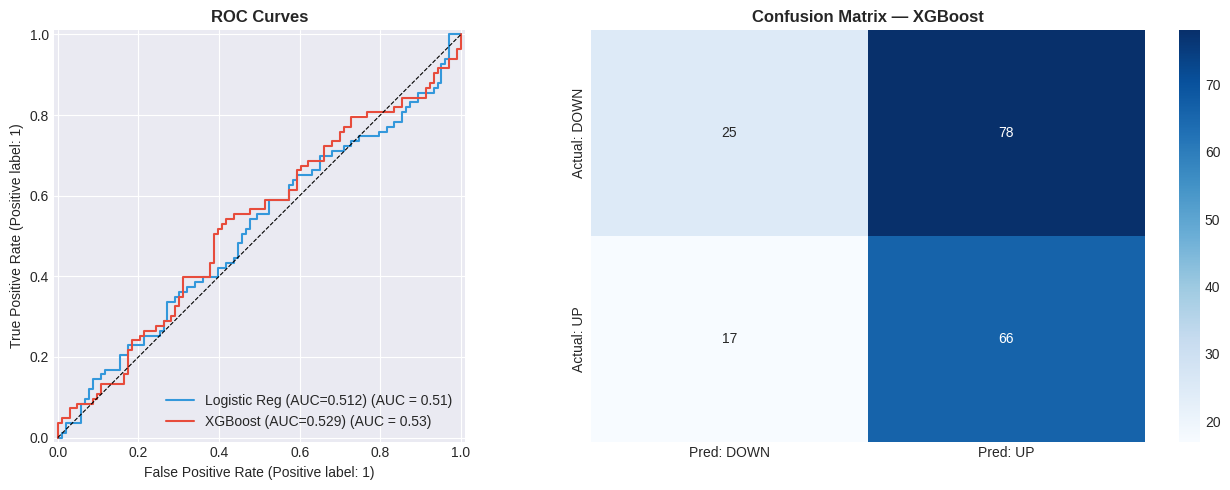

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, lr.predict_proba(X_test_sc)[:, 1],
    name=f'Logistic Reg (AUC={auc_lr:.3f})', ax=axes[0], color='#3498db'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    name=f'XGBoost (AUC={auc_xgb:.3f})', ax=axes[0], color='#e74c3c'
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC Curves', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: DOWN', 'Pred: UP'],
            yticklabels=['Actual: DOWN', 'Actual: UP'])
axes[1].set_title('Confusion Matrix — XGBoost', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 13. SHAP — Feature Importance

Computing SHAP values...


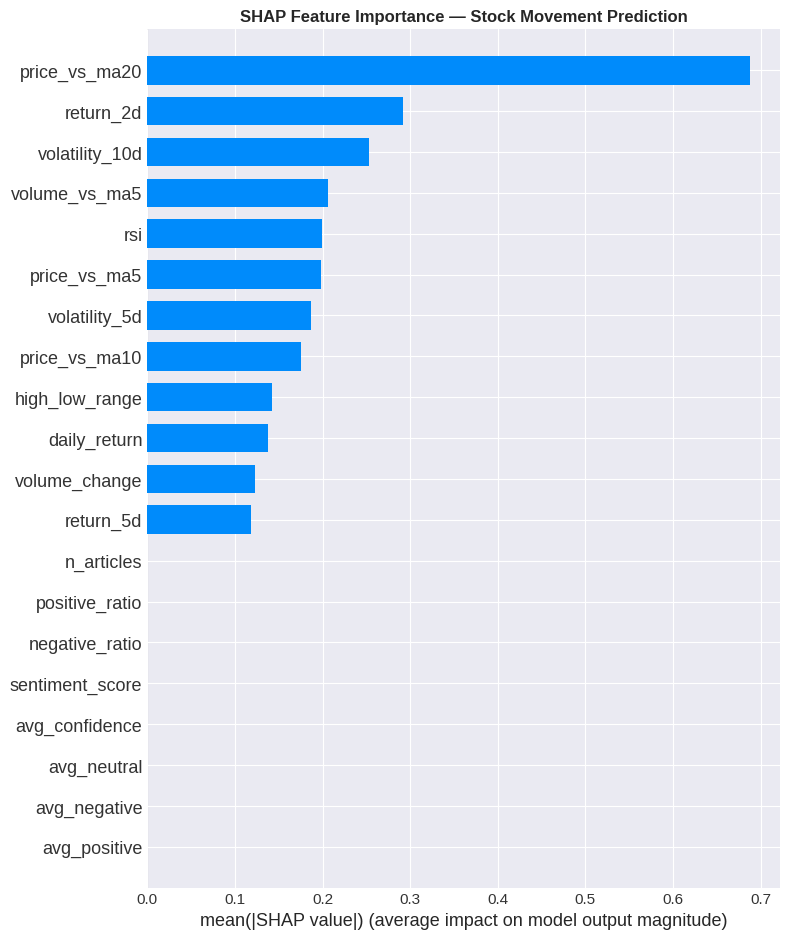

In [106]:
print('Computing SHAP values...')
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Stock Movement Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

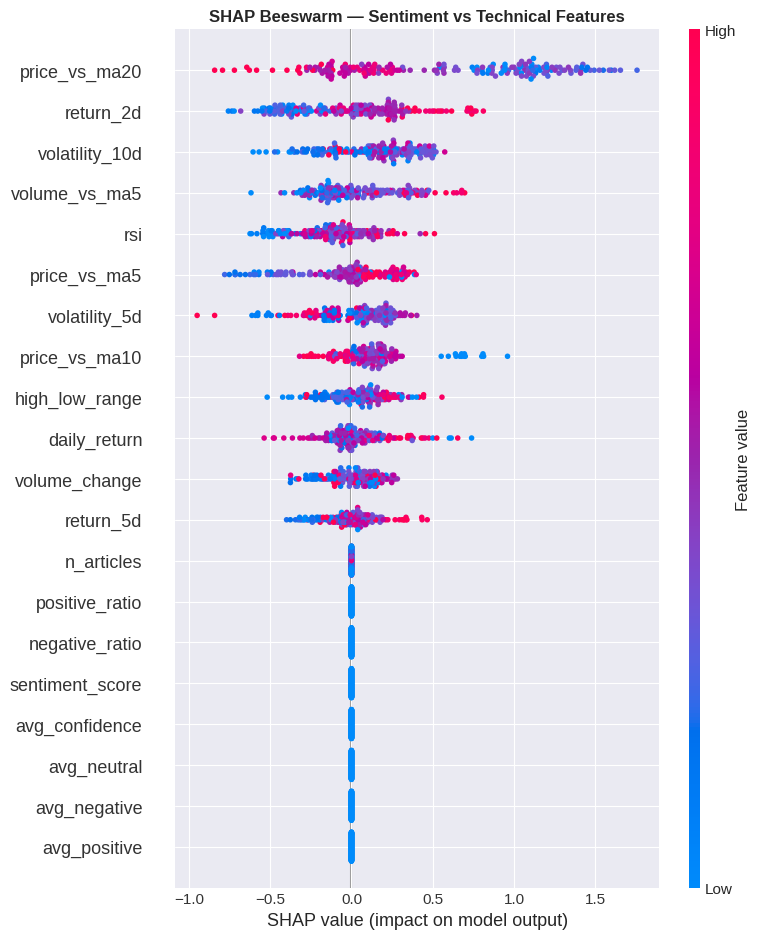

In [107]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Sentiment vs Technical Features', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Sentiment vs Price Movement Analysis

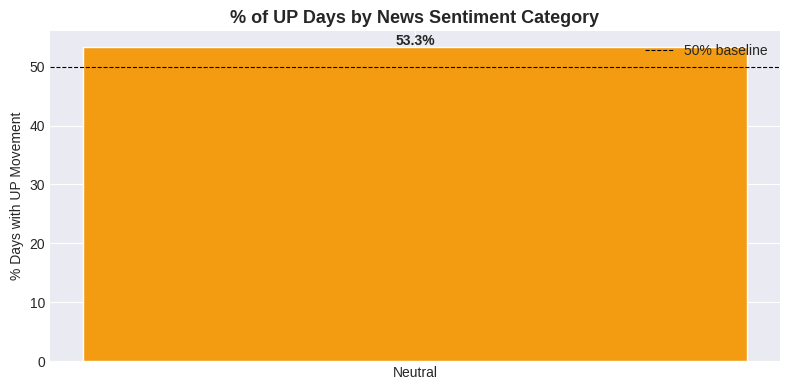

In [108]:
# Does positive sentiment actually predict UP movement?
analysis_df = model_df.copy()
analysis_df['sent_bucket'] = pd.cut(
    analysis_df['sentiment_score'],
    bins=[-1, -0.1, 0.1, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

up_by_sentiment = analysis_df.groupby('sent_bucket')['target'].mean() * 100

plt.figure(figsize=(8, 4))
bars = plt.bar(up_by_sentiment.index, up_by_sentiment.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
plt.axhline(50, color='black', linestyle='--', linewidth=0.8, label='50% baseline')
plt.title('% of UP Days by News Sentiment Category', fontsize=13, fontweight='bold')
plt.ylabel('% Days with UP Movement')
for bar, val in zip(bars, up_by_sentiment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 15. Save Model

In [110]:
joblib.dump(xgb_model, 'xgb_sentiment_model.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

# Save sentiment data for reference
news_df.to_csv('news_sentiment.csv', index=False)

print('Saved:')
print('  xgb_sentiment_model.pkl')
print('  feature_columns.pkl')
print('  news_sentiment.csv')

import os
print('\nFiles:', os.listdir('.'))

Saved:
  xgb_sentiment_model.pkl
  feature_columns.pkl
  news_sentiment.csv

Files: ['feature_columns.pkl', 'xgb_sentiment_model.pkl', 'news_sentiment.csv', '.virtual_documents']
